/tmp/ipykernel_23260/2146351795.py:45: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x="metoda", y="czas [ms]", scale="width", inner="quartile", ax=axes[0,0])


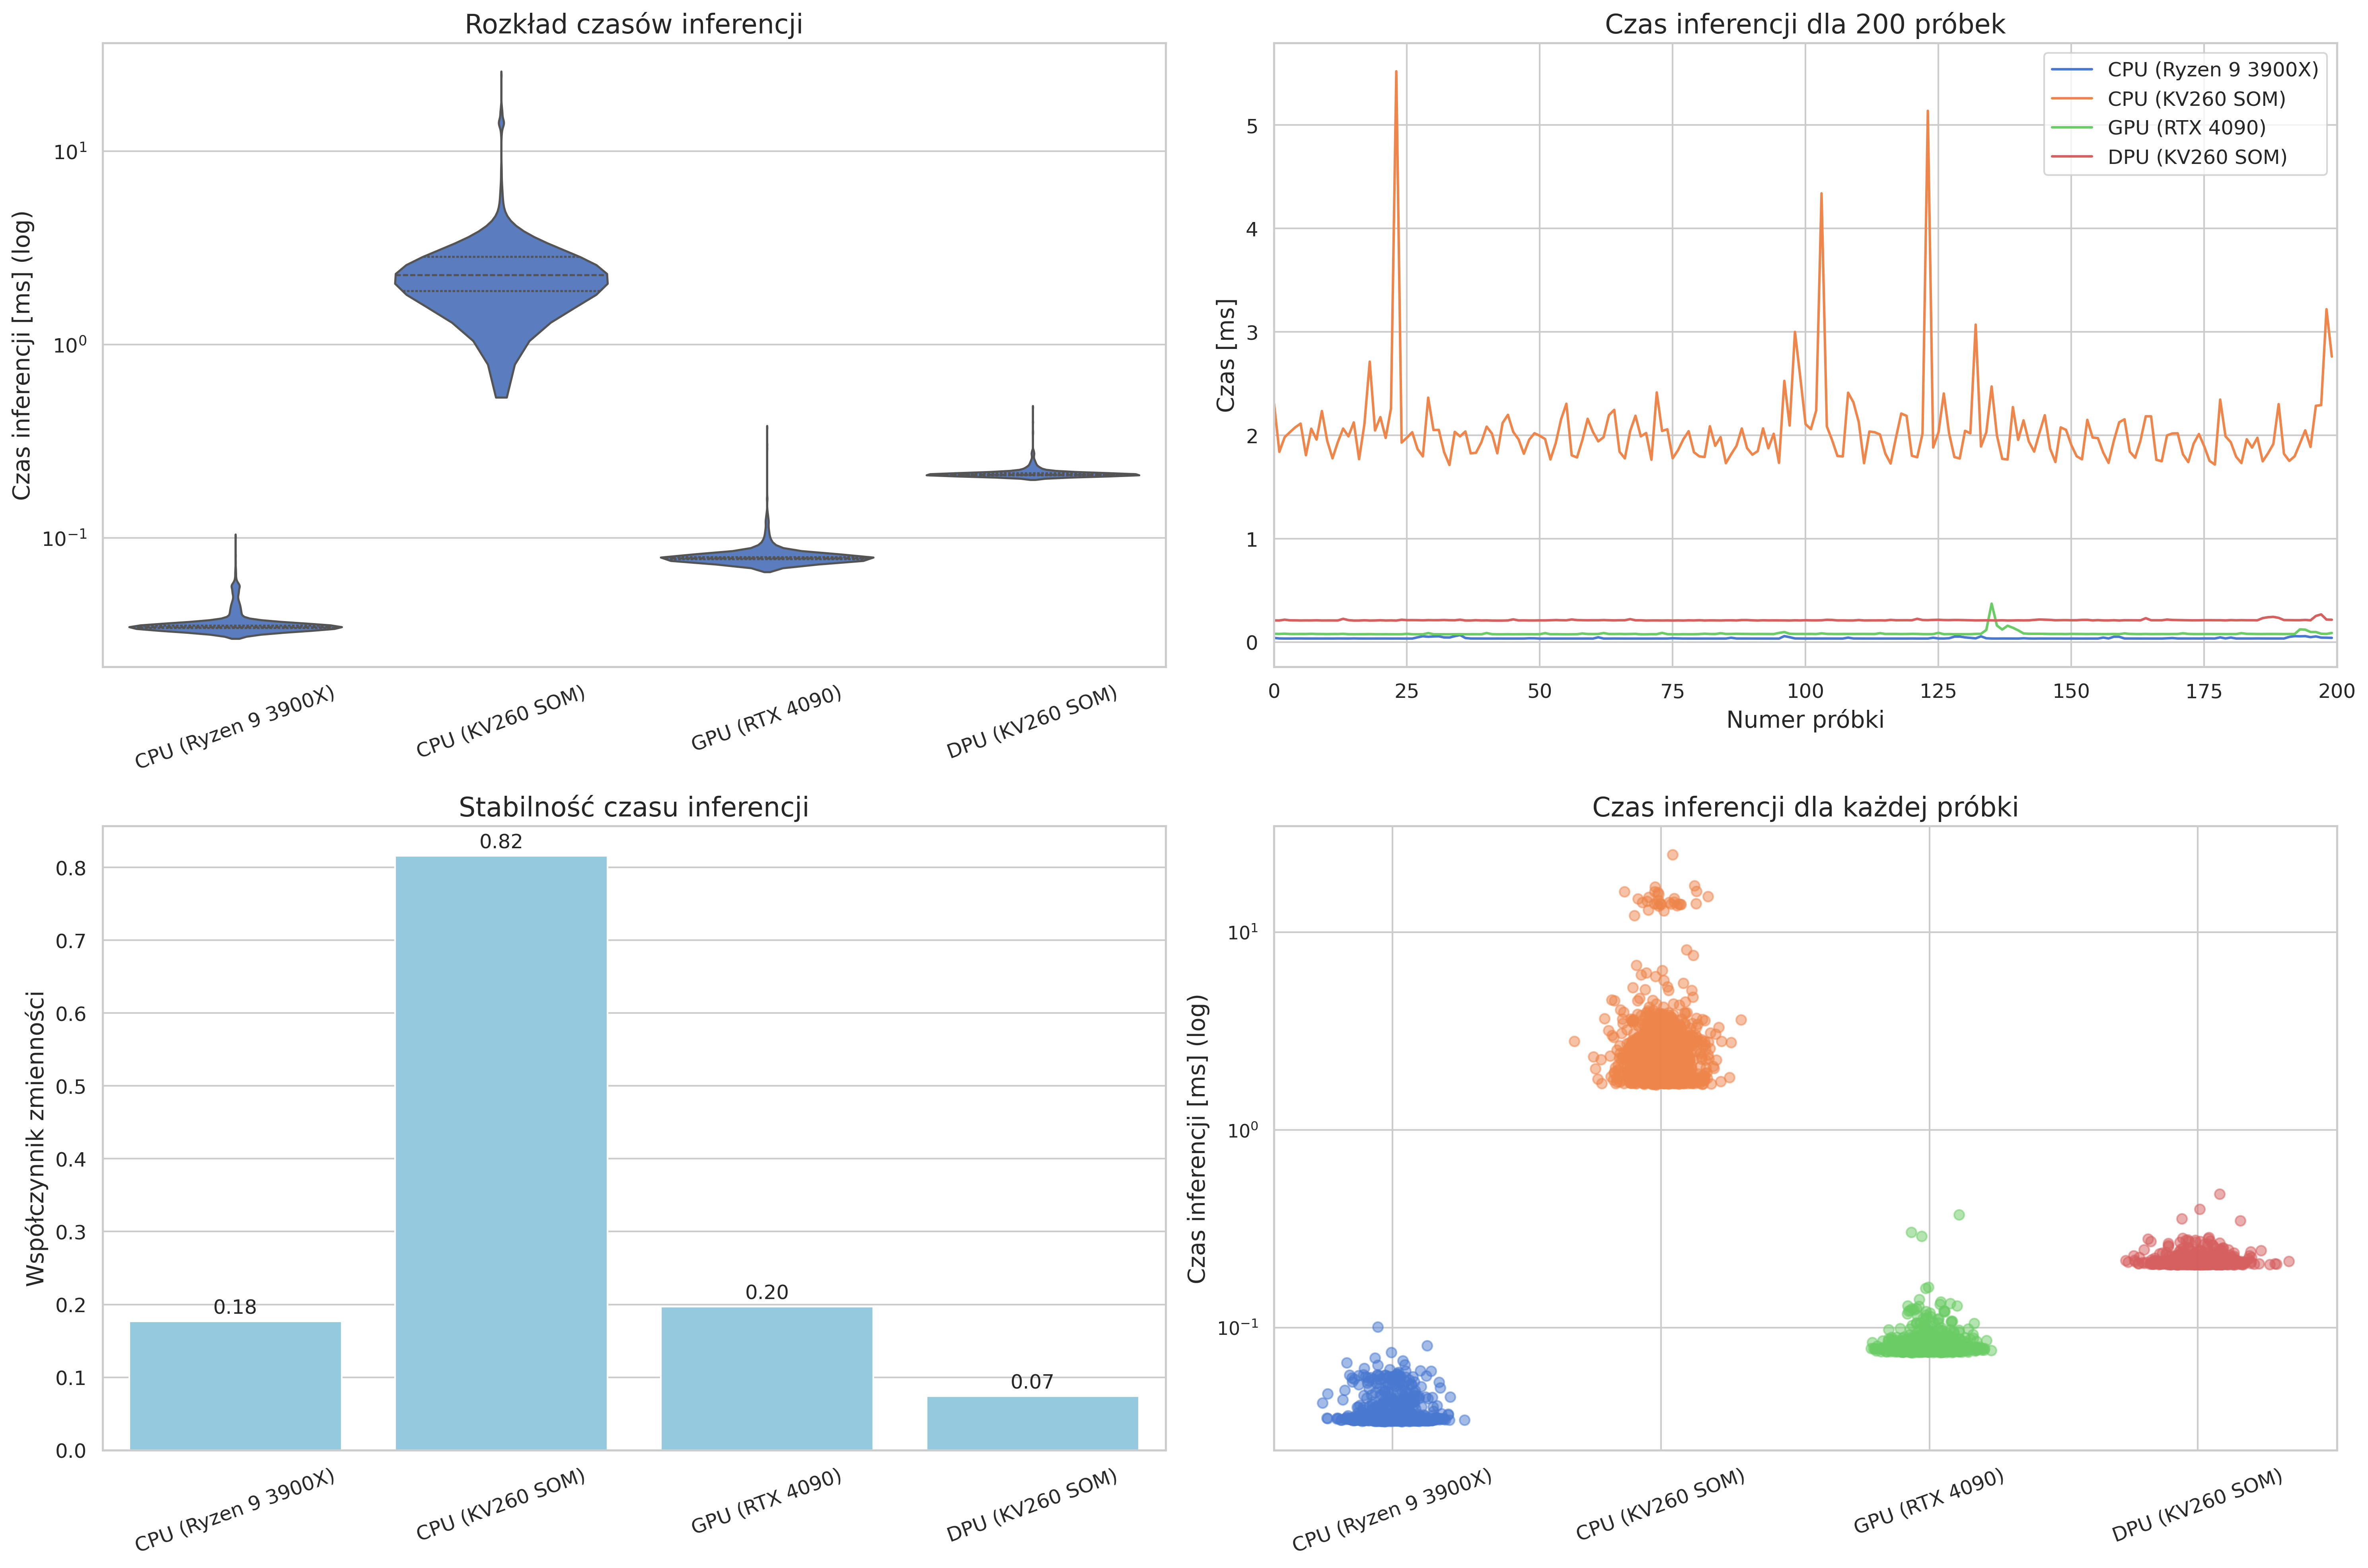

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", palette="muted", font="DejaVu Sans")

# Wczytaj dane
dpu_stats = np.load("data/dpu_inference_stats.npy", allow_pickle=True).item()
cuda_stats = np.load("data/cuda_inference_stats.npy", allow_pickle=True).item()
cpu_stats = np.load("data/cpu_inference_stats.npy", allow_pickle=True).item()
cpu_zynq_stats = np.load("data/cpu_zynq_inference_stats.npy", allow_pickle=True).item()

skip = 5
times_dict = {
    "CPU (Ryzen 9 3900X)": cpu_stats["times"][skip:],
    "CPU (KV260 SOM)": cpu_zynq_stats["times"][skip:],
    "GPU (RTX 4090)": cuda_stats["times"][skip:],
    "DPU (KV260 SOM)": dpu_stats["times"][skip:]
}

# DataFrame do seaborn
df = pd.DataFrame({
    "czas [ms]": np.concatenate([t * 1000 for t in times_dict.values()]),
    "metoda": np.concatenate([[k]*len(v) for k, v in times_dict.items()])
})

# Stabilność (CV)
stability_metrics = {}
for metoda, t in times_dict.items():
    mean_t = np.mean(t)
    std_t = np.std(t)
    cv = std_t / mean_t
    stability_metrics[metoda] = cv

df_stability = pd.DataFrame({
    "metoda": list(stability_metrics.keys()),
    "CV": list(stability_metrics.values())
})

# 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(20, 14), dpi=300)

# 1. Violinplot
sns.violinplot(data=df, x="metoda", y="czas [ms]", scale="width", inner="quartile", ax=axes[0,0])
axes[0,0].set_yscale("log")
axes[0,0].set_title("Rozkład czasów inferencji", fontsize=16)
axes[0,0].tick_params(axis="x", rotation=20, labelsize=12)
axes[0,0].tick_params(axis="y", labelsize=12)
axes[0,0].set_ylabel("Czas inferencji [ms] (log)", fontsize=14)
axes[0,0].set_xlabel("") 

# 2. Trend
for metoda, t in times_dict.items():
    axes[0,1].plot(t[:200]*1000, label=metoda)
axes[0,1].set_title("Czas inferencji dla 200 próbek", fontsize=16)
axes[0,1].set_xlabel("Numer próbki", fontsize=14)
axes[0,1].set_xlim(0, 200)
axes[0,1].set_ylabel("Czas [ms]", fontsize=14)
axes[0,1].tick_params(axis="x", labelsize=12)
axes[0,1].tick_params(axis="y", labelsize=12)
axes[0,1].legend(fontsize=12)

# 3. Stabilność (CV)
ax = sns.barplot(data=df_stability, x="metoda", y="CV", color="skyblue", ax=axes[1,0])
axes[1,0].set_title("Stabilność czasu inferencji", fontsize=16)
axes[1,0].set_ylabel("Współczynnik zmienności", fontsize=14)
axes[1,0].tick_params(axis="x", rotation=20, labelsize=12)
axes[1,0].tick_params(axis="y", labelsize=12)
# dodanie wartości nad słupkami
for i, row in df_stability.iterrows():
    ax.text(i, row["CV"] + 0.005, f"{row['CV']:.2f}", ha='center', va='bottom', fontsize=12)
axes[1,0].set_xlabel("")

# 4. Scatter plot z jitterem i log-scalą
for i, (metoda, t) in enumerate(times_dict.items()):
    x_jitter = np.random.normal(loc=i, scale=0.08, size=len(t))
    axes[1,1].scatter(x_jitter, t*1000, alpha=0.5, label=metoda)
axes[1,1].set_yscale("log")
axes[1,1].set_xticks(range(len(times_dict)))
axes[1,1].set_xticklabels(list(times_dict.keys()), rotation=20, fontsize=12)
axes[1,1].set_ylabel("Czas inferencji [ms] (log)", fontsize=14)
axes[1,1].set_title("Czas inferencji dla każdej próbki", fontsize=16)
# axes[1,1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [74]:
import numpy as np
import pandas as pd

# Pominięcie pierwszych próbek
times_dict = {
    "CPU (Ryzen 9 3900X)": cpu_stats["times"],
    "CPU (KV260 SOM)": cpu_zynq_stats["times"],
    "GPU (RTX 4090)": cuda_stats["times"],
    "DPU (KV260 SOM)": dpu_stats["times"]
}

summary_data = []

for metoda, t in times_dict.items():
    t_ms = np.array(t) * 1000            # konwersja na ms
    mean_time = np.mean(t_ms)
    std_time = np.std(t_ms)
    median_time = np.median(t_ms)
    freq_khz = (1 / mean_time)
    summary_data.append({
        "Platforma": metoda,
        "Średni czas [ms]": mean_time,
        "Odchylenie [ms]": std_time,
        "Mediana [ms]": median_time,
        "Średnia częstotliwość [kHz]": freq_khz
    })

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.round(4)
df_summary


,Platforma,Średni czas [ms],Odchylenie [ms],Mediana [ms],Średnia częstotliwość [kHz]
0,CPU (Ryzen 9 3900X),0.0374,0.0098,0.0347,26.7698
1,CPU (KV260 SOM),2.8319,2.3080,2.2971,0.3531
2,GPU (RTX 4090),0.1591,2.4342,0.0786,6.2840
3,DPU (KV260 SOM),0.2177,0.0189,0.2131,4.5941


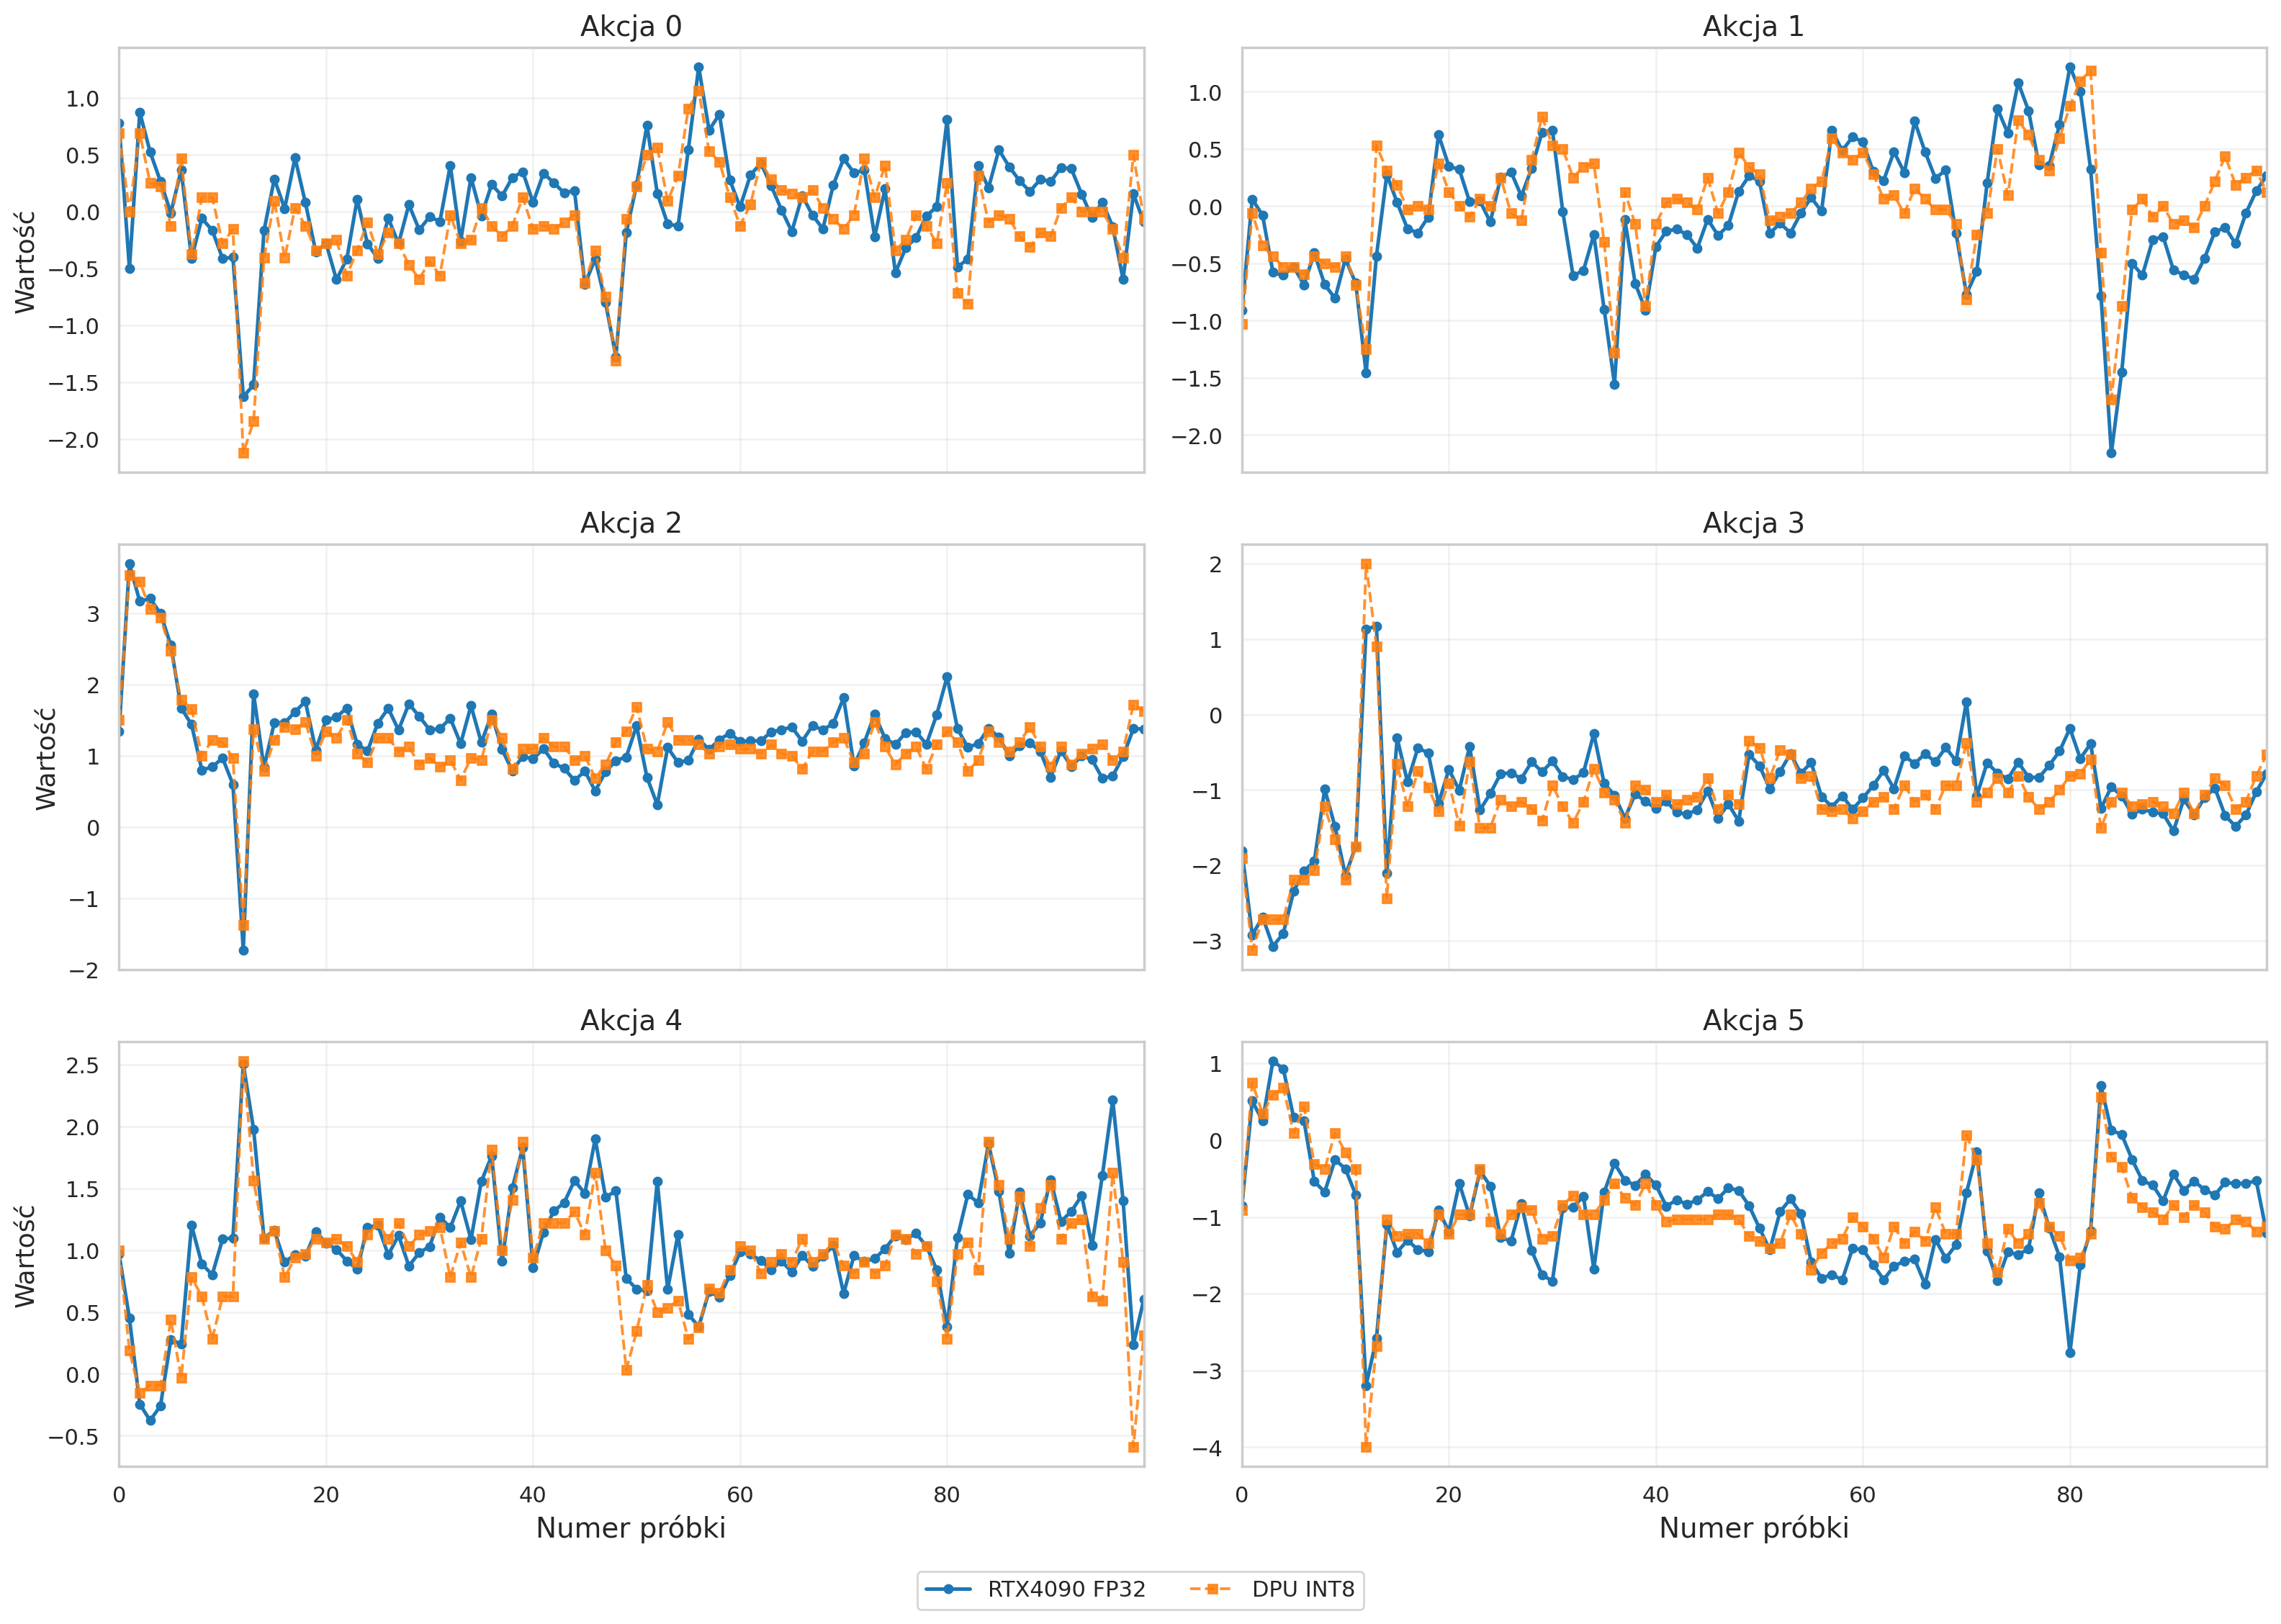

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font="DejaVu Sans")

# Wczytanie danych
bernard_actions = np.load("data/bernard_actions.npy")  # DPU int8
ref_actions = np.load("data/ref_actions.npy")          # GPU fp32
obs0 = np.load("data/obs0.npy")                        # fazy chodu

num_actions = bernard_actions.shape[1]
num_samples = 100
action_names = [f"Akcja {i}" for i in range(1, num_actions+1)]

# Kolory i styl jak w przykładzie FP32/QAT
colors = {
    'fp32': '#1f77b4',   # niebieski
    'dpu': '#ff7f0e',    # pomarańczowy
}

fig, axes = plt.subplots(3, 2, figsize=(16,12), dpi=200, sharex=True)
axes = axes.flatten()

for d in range(num_actions):
    ax = axes[d]
    # GPU FP32
    ax.plot(ref_actions[:num_samples,d], marker='o', linestyle='-', linewidth=1.8, markersize=4,
            label='RTX4090 FP32' if d == 0 else None, color=colors['fp32'])
    # DPU INT8
    ax.plot(bernard_actions[:num_samples,d], marker='s', linestyle='--', linewidth=1.4, markersize=4,
            label='DPU INT8' if d == 0 else None, color=colors['dpu'], alpha=0.85)

    ax.set_title(f'Akcja {d}', fontsize=14)
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=11)
    ax.set_xlim([0, num_samples-1])

# Oś wspólna
for ax in axes:
    ax.set_xlim(left=0)
axes[-2].set_xlabel('Numer próbki', fontsize=14)
axes[-1].set_xlabel('Numer próbki', fontsize=14)
for row in range(3):
    axes[row*2].set_ylabel('Wartość', fontsize=13)

# Legendy pod wykresami
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=4, fontsize=11, frameon=True)

plt.tight_layout(rect=(0,0.04,1,0.955))
plt.show()


In [61]:
# Wczytanie danych
bernard_actions = np.load("data/bernard_actions.npy")  # DPU int8
ref_actions = np.load("data/ref_actions.npy")          # GPU fp32

# Obliczenie MSE
mse = np.mean((bernard_actions - ref_actions)**2)
print(f"MSE między referencyjnym sterowaniem a DPU: {mse:.6f}")

# Dodatkowo można policzyć MSE dla każdej akcji osobno
mse_per_action = np.mean((bernard_actions - ref_actions)**2, axis=0)
for i, val in enumerate(mse_per_action):
    print(f"MSE Akcja {i+1}: {val:.6f}")

MSE między referencyjnym sterowaniem a DPU: 0.101409
MSE Akcja 1: 0.073929
MSE Akcja 2: 0.142414
MSE Akcja 3: 0.074816
MSE Akcja 4: 0.085733
MSE Akcja 5: 0.093593
MSE Akcja 6: 0.137968
